# ESG Financial Performance Analysis

## Operational Setup

The following setup cells import required libraries, load the dataset and create derived variables used throughout the analysis. They are kept at the beginning to ensure that the notebook can be rerun from top to bottom.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("../data/company_esg_financial_dataset.csv")

df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:
df = df.sort_values(["CompanyID","Year"])

df["ESG_Growth"] = (
    df.groupby("CompanyID")["ESG_Overall"]
      .pct_change()*100
)

## Project Introduction

### Project Objective

This project explores the relationship between ESG performance and financial indicators across 1,000 simulated global companies between 2015 and 2025.

The analysis investigates sector-specific sustainability patterns, valuation dynamics and temporal ESG trends using exploratory analytics techniques. The goal of this analysis is to answer the question:

“How do ESG characteristics differ across industries and regions, and how are ESG metrics related to financial performance?”

### Dataset Overview
The synthetic dataset contains:

- **1,000 companies**
- **11 years** of annual observations
- **9 industries**
- **7 geographic regions**
- Financial and ESG indicators
- Environmental resource metrics

Total observations: **11,000**

The dataset enables analysis across temporal, geographic, industry and financial dimensions to identify drivers of **ESG performance**.

### Data Quality Assessment
The synthetic dataset contains minimal missing values. Missing observations occur exclusively within the original **GrowthRate** variable, where first-year observations cannot be calculated because no prior-year reference exists.

A derived **ESG_Growth** variable was created for the analysis and follows the same logic: the first observation for each company has no prior-year ESG score and is therefore excluded from growth-based calculations.

### Methodology
The analysis combines exploratory and statistical techniques to identify patterns and evaluate drivers of ESG performance:

- Exploratory data analysis to identify distributions and anomalies  
- Industry comparisons to assess sector differences  
- Temporal trend analysis to examine ESG development over time  
- Correlation analysis to evaluate financial–ESG relationships  
- Variance decomposition to compare industry and revenue explanatory relevance  
- DAX-based business metrics for dashboard insights

## Exploratory Data Analysis
The exploratory data analysis examines ESG performance across industries, regions, time and financial indicators. The goal is to identify structural patterns before validating selected findings through statistical analysis.

### ESG Patterns Across Industries

#### Average ESG Score Over Time

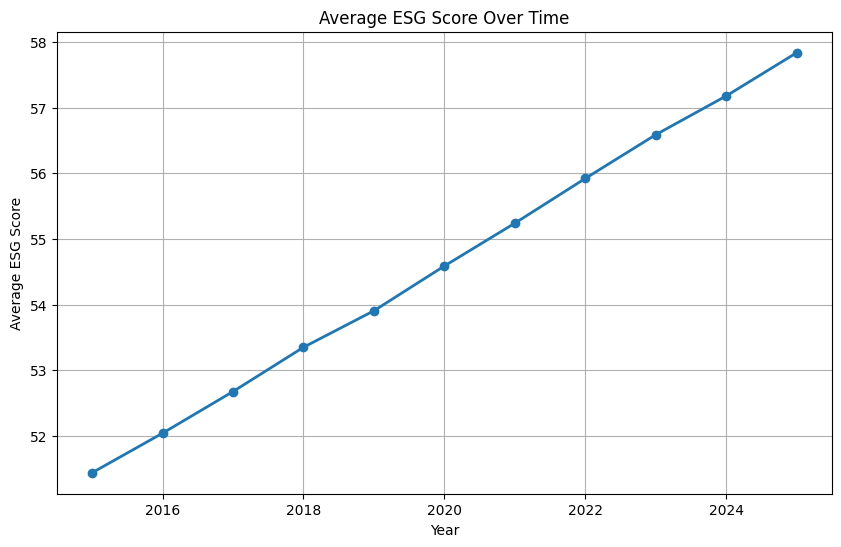

In [4]:
yearly_esg = df.groupby("Year")["ESG_Overall"].mean()

plt.figure(figsize=(10,6))

yearly_esg.plot(
    marker="o",
    linewidth=2
)

plt.title("Average ESG Score Over Time")

plt.xlabel("Year")

plt.ylabel("Average ESG Score")

plt.grid(True)

plt.show()

##### Insights
Average ESG scores increase steadily throughout the observation period, rising from approximately **52 points in 2015** to nearly **58 points in 2025**. The consistent upward trajectory suggests a broad improvement in sustainability performance across the dataset, reflecting growing ESG adoption and reporting maturity over time.


#### Average ESG Score by Industry

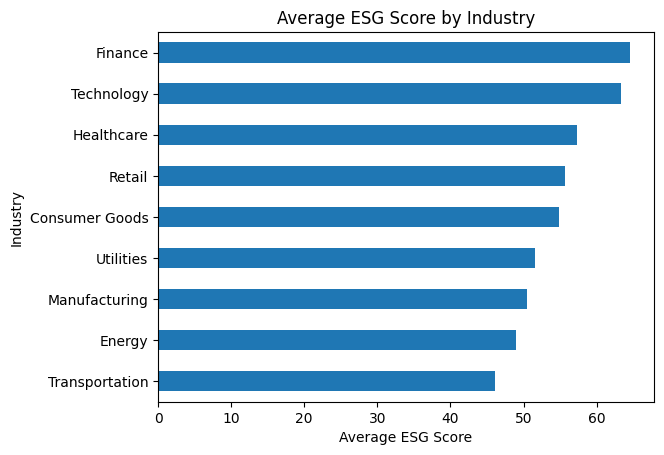

In [5]:
industry_esg = df.groupby("Industry")["ESG_Overall"].mean().sort_values()

industry_esg.plot(kind="barh")

plt.title("Average ESG Score by Industry")

plt.xlabel("Average ESG Score")

plt.ylabel("Industry")

plt.show()

##### Insights
**Finance** and **Technology** achieve the highest average ESG scores, while **Energy** and **Transportation** rank lowest. The results suggest that ESG performance varies substantially across industries, indicating the presence of **sector-specific sustainability characteristics**.

#### Relative ESG Improvement by Industry

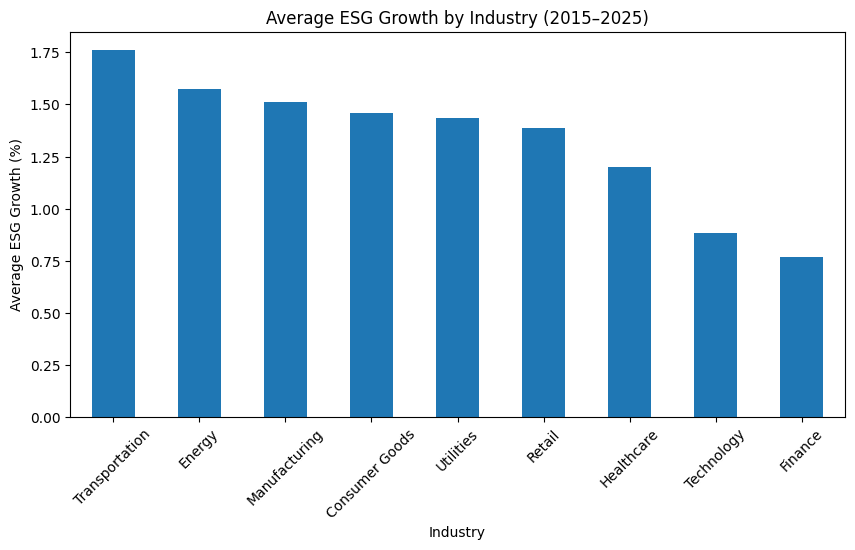

In [6]:
industry_growth = (
    df.groupby("Industry")["ESG_Growth"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

industry_growth.plot(kind="bar")

plt.title("Average ESG Growth by Industry (2015–2025)")
plt.ylabel("Average ESG Growth (%)")
plt.xlabel("Industry")

plt.xticks(rotation=45)

plt.show()

##### Insights
**Transportation** and **Energy** demonstrate the highest average ESG growth rates, indicating substantial sustainability progress over the observed period. In contrast, **Finance** and **Technology** maintain leading ESG scores but exhibit slower relative growth, suggesting a more mature sustainability profile with less room for improvement.

The results highlight the importance of distinguishing between **ESG performance levels** and **ESG improvement rates**. Industries that currently rank lower in ESG performance may nevertheless be making the most significant progress toward stronger sustainability outcomes.

#### Indexed ESG Development by Selected Industries

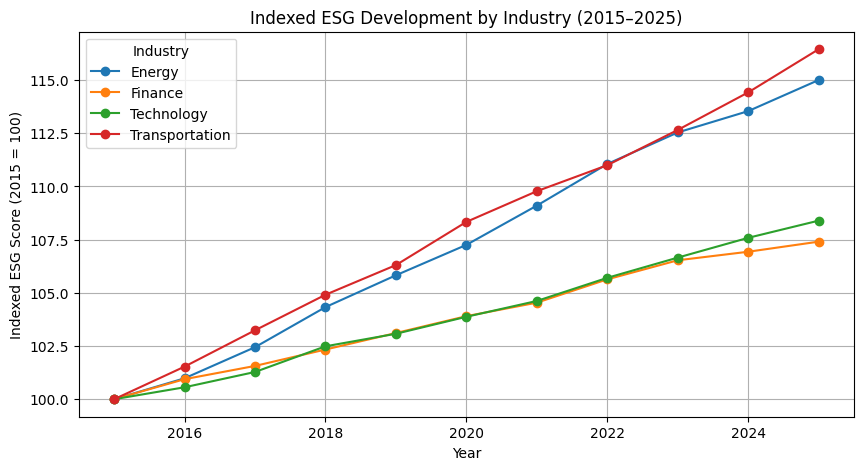

In [7]:
selected_industries = ["Energy", "Finance", "Technology", "Transportation"]

industry_yearly_esg = (
    df[df["Industry"].isin(selected_industries)]
    .groupby(["Year", "Industry"])["ESG_Overall"]
    .mean()
    .reset_index()
)

industry_yearly_esg["Indexed_ESG"] = (
    industry_yearly_esg
    .groupby("Industry")["ESG_Overall"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

plt.figure(figsize=(10, 5))

for industry in selected_industries:
    subset = industry_yearly_esg[industry_yearly_esg["Industry"] == industry]
    plt.plot(
        subset["Year"],
        subset["Indexed_ESG"],
        marker="o",
        label=industry
    )

plt.title("Indexed ESG Development by Industry (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Indexed ESG Score (2015 = 100)")
plt.legend(title="Industry")
plt.grid(True)

plt.show()

##### Insights
The indexed view makes the relative pace of change more visible by setting all selected industries to the same baseline in 2015. This helps compare ESG development trajectories independently from their absolute starting levels.

#### Average Carbon Emissions by Industry

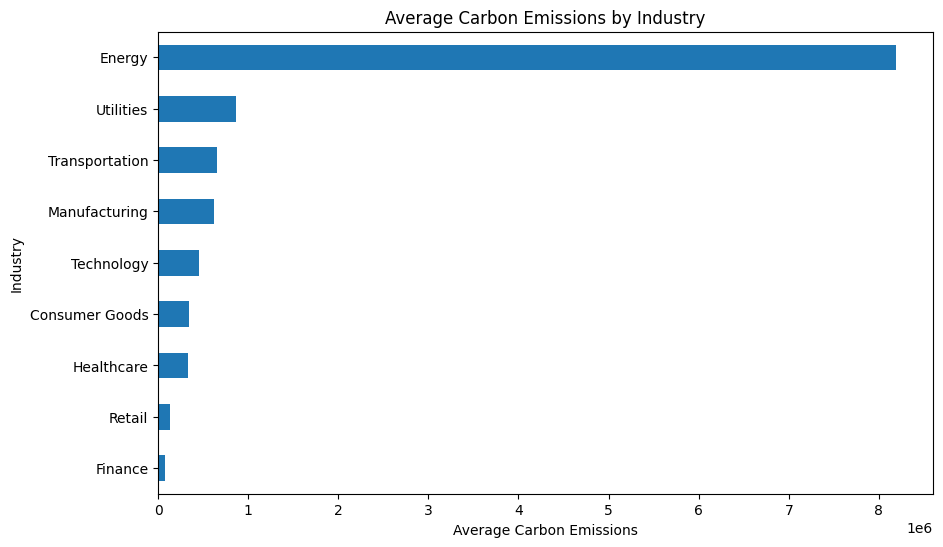

In [8]:
industry_emissions = (
    df.groupby("Industry")["CarbonEmissions"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

industry_emissions.plot(kind="barh")

plt.title("Average Carbon Emissions by Industry")

plt.xlabel("Average Carbon Emissions")

plt.ylabel("Industry")

plt.show()

##### Insights
The **Energy** sector exhibits substantially higher average carbon emissions than all other industries in the dataset. **Utilities**, **Manufacturing** and **Transportation** also display comparatively elevated emission levels, while **Finance** and **Retail** maintain significantly lower operational emissions.

This distribution aligns with real-world expectations, where heavy industrial and energy-intensive sectors generally face greater environmental impact and sustainability challenges than service-oriented industries.

#### Key Takeaways
- ESG performance improved consistently across the dataset between 2015 and 2025, indicating a broad upward sustainability trend across industries.
- ESG outcomes differ considerably between industries, suggesting that sector-specific characteristics play an important role in shaping sustainability performance.
- Finance and Technology achieve the highest overall ESG scores, while Transportation and Energy rank lower in absolute ESG performance.
- High ESG performance does not necessarily imply high ESG growth. Transportation and Energy exhibit the strongest improvement rates, whereas Finance and Technology maintain high ESG levels but show slower relative growth.
- Carbon emissions remain concentrated in energy-intensive industries, highlighting structural sustainability challenges that vary substantially across sectors.
- The findings support the use of industry-specific ESG strategies and demonstrate the importance of evaluating both current ESG performance and long-term ESG development.

### ESG Patterns Across Regions

#### Average ESG Score by Region

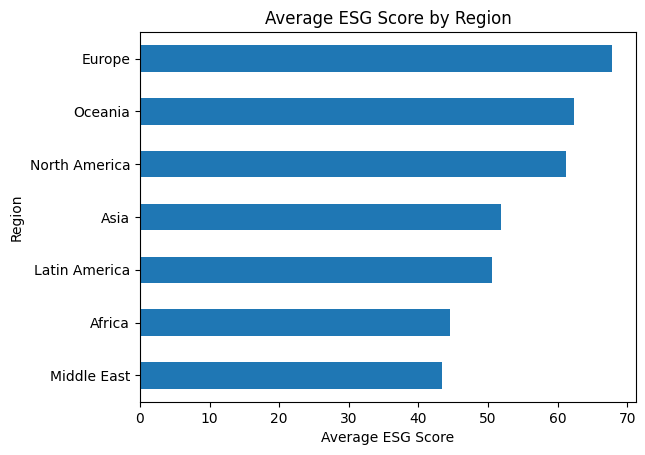

In [9]:
region_esg = df.groupby("Region")["ESG_Overall"].mean().sort_values()

region_esg.plot(kind="barh")

plt.title("Average ESG Score by Region")

plt.xlabel("Average ESG Score")

plt.ylabel("Region")

plt.show()

##### Insights
Average ESG scores vary noticeably across regions. **Europe** records the highest average ESG score in the dataset, followed by **Oceania** and **North America**. **Asia** and **Latin America** occupy middle positions, while **Africa** and the **Middle East** report comparatively lower average ESG scores.

The gap between the highest- and lowest-ranked regions exceeds **20 ESG points**, indicating substantial regional variation in sustainability performance across the sample.

##### Key Takeaways
- ESG performance varies considerably across geographic regions.
- Europe, Oceania and North America achieve the highest average ESG scores, while Africa and the Middle East rank lower.
- Regional differences may reflect variations in regulation, reporting maturity and market expectations.
- ESG performance is influenced not only by company-level factors but also by broader geographic and institutional environments.

### ESG and Financial Performance

#### Revenue vs ESG Score by Industry

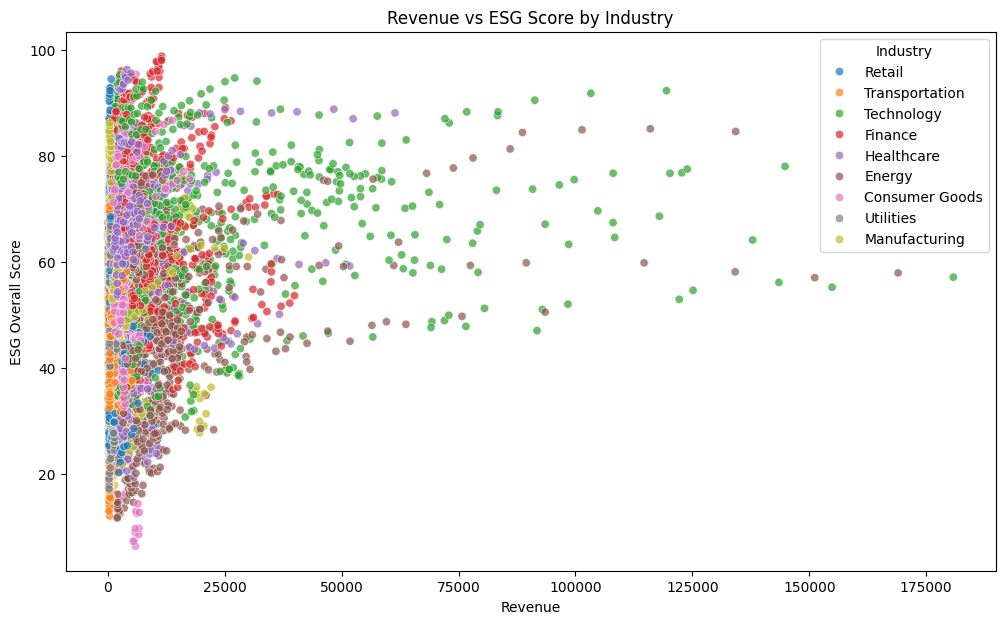

In [10]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x="Revenue",
    y="ESG_Overall",
    hue="Industry",
    alpha=0.7
)

plt.title("Revenue vs ESG Score by Industry")

plt.xlabel("Revenue")

plt.ylabel("ESG Overall Score")

plt.show()

##### Insights
Visual inspection suggests that revenue has only **a weak positive relationship** with ESG performance. While higher-revenue firms tend to achieve slightly higher ESG scores on average, substantial variation exists across companies and industries. To quantify this relationship, a correlation analysis was conducted in the **Statistical Analysis** section. Industry-specific clustering is also observable. **Technology** companies in particular occupy a broad range of high-revenue positions while maintaining comparatively strong ESG performance. In contrast, some sectors display weaker ESG performance despite lower or moderate revenue levels.

Overall, the visualization suggests that revenue is a **weak predictor of ESG outcomes**.

#### Revenue vs ESG Score Without Dominant Sectors

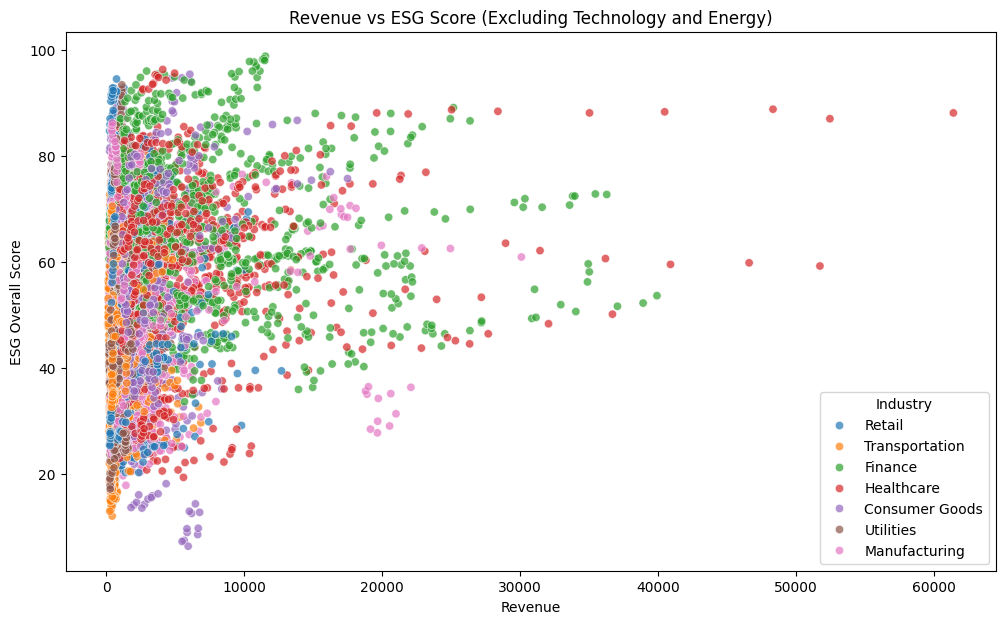

In [11]:
filtered_df = df[
    ~df["Industry"].isin(["Technology", "Energy"])
]

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=filtered_df,
    x="Revenue",
    y="ESG_Overall",
    hue="Industry",
    alpha=0.7
)

plt.title("Revenue vs ESG Score (Excluding Technology and Energy)")

plt.xlabel("Revenue")

plt.ylabel("ESG Overall Score")

plt.show()

##### Insights
After excluding the dominant **Technology** and **Energy** sectors, the distribution of the remaining industries becomes clearer. Revenue levels across sectors appear more comparable, allowing **industry-specific ESG patterns** to become more visible.
The adjusted visualization suggests that ESG performance varies considerably among similar revenue level firms, reinforcing the idea that financial scale alone does not determine sustainability outcomes.

##### Key Takeaways
- Companies with similar revenue levels often display substantially different ESG outcomes.
- Industry characteristics explain a larger share of ESG variation than financial scale alone.
- Removing dominant sectors reveals that ESG differences persist even among firms with comparable revenue levels.
- Strong financial performance and strong ESG performance are not mutually exclusive, but revenue alone is not a reliable predictor of sustainability outcomes.

### Top Performing Companies

#### Top Companies by Average ESG Performance

In [12]:
company_esg = (
    df.groupby(["CompanyName", "Industry", "Region"])["ESG_Overall"]
    .mean()
    .reset_index()
    .sort_values(by="ESG_Overall", ascending=False)
)

company_esg.head(10)

,CompanyName,Industry,Region,ESG_Overall
421,Company_478,Finance,Europe,96.918182
415,Company_472,Healthcare,Europe,94.200000
283,Company_353,Finance,Europe,93.763636
857,Company_870,Finance,Latin America,92.654545
384,Company_444,Finance,Europe,91.609091
125,Company_210,Retail,Oceania,91.100000
569,Company_610,Technology,Europe,90.872727
964,Company_967,Technology,Europe,90.872727
65,Company_157,Consumer Goods,Europe,90.818182
310,Company_378,Technology,Oceania,90.727273


##### Insights
Highest average ESG performers are concentrated primarily within the **Finance** sector, with additional strong performers appearing in **Healthcare**, **Technology**, **Retail and Consumer Goods** industries. Several companies maintain consistently elevated ESG scores across the full reporting period, suggesting sustained emphasis on governance, sustainability practices and social responsibility.

The concentration of leading ESG performers in comparatively less resource-intensive industries may suggest structural differences in how ESG performance is achieved and assessed across sectors.

#### Top Companies by Average Revenue

In [13]:
company_revenue = (
    df.groupby(["CompanyName", "Industry"])["Revenue"]
    .mean()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
)

company_revenue.head(10)

,CompanyName,Industry,Revenue
101,Company_19,Technology,110239.145455
405,Company_463,Technology,102164.509091
733,Company_759,Energy,86731.809091
608,Company_646,Energy,81498.490909
1,Company_10,Technology,80590.872727
552,Company_596,Technology,62628.063636
28,Company_123,Technology,61640.654545
736,Company_761,Technology,59143.290909
285,Company_355,Technology,53260.281818
128,Company_213,Technology,53252.372727


##### Insights
**Technology** and **Energy** firms dominate the highest revenue rankings within the dataset. **Technology** companies in particular occupy several of the leading positions, highlighting the scale advantages often associated with digital business models and global market reach.

The concentration of Energy firms among top revenue performers further illustrates the capital-intensive and economically significant nature of resource-driven industries.

#### Top Companies by Average Market Capitalization

In [14]:
company_marketcap = (
    df.groupby(["CompanyName", "Industry"])["MarketCap"]
    .mean()
    .reset_index()
    .sort_values(by="MarketCap", ascending=False)
)

company_marketcap.head(10)

,CompanyName,Industry,MarketCap
405,Company_463,Technology,492368.890909
128,Company_213,Technology,331972.527273
1,Company_10,Technology,300846.872727
28,Company_123,Technology,288390.154545
276,Company_347,Technology,270720.527273
285,Company_355,Technology,262039.190909
552,Company_596,Technology,252052.454545
736,Company_761,Technology,231738.836364
733,Company_759,Energy,219072.645455
210,Company_288,Technology,205123.572727


##### Insights
**Technology** companies dominate the upper end of the market capitalization distribution, accounting for nearly all of the highest average market valuations in the dataset. This pattern reflects the strong valuation potential commonly associated with scalable and innovation-driven business models.

While **Energy** firms also appear among the largest companies by market capitalization, the **Technology** sector demonstrates substantially greater concentration among the top-ranked firms overall.

#### Key Takeaways
- The highest ESG-performing companies are concentrated primarily in Finance, while Technology firms dominate both revenue and market capitalization rankings.
- Strong financial performance does not necessarily coincide with the highest ESG scores. Different industries tend to lead different dimensions of performance, highlighting the multifaceted nature of corporate success.
- Technology companies demonstrate exceptional economic scale and market valuation, whereas Finance firms achieve the strongest sustainability performance on average.
- The findings reinforce earlier results suggesting that industry characteristics influence both ESG outcomes and financial performance, although the relationship between the two remains relatively weak.
- Overall, the leading companies illustrate that ESG leadership and financial leadership can coexist, but they are not consistently driven by the same firms or industries.

## Statistical Analysis

### Revenue–ESG Correlation

#### Methodology
To quantify the relationship between company revenue and ESG performance, the Pearson correlation coefficient was calculated. The coefficient measures the strength and direction of a linear relationship between two variables and ranges from -1 to +1.
#### Formula
r = covariance(X,Y) / (σX × σY)
#### Result
**Revenue–ESG Correlation ~ 0.15**
#### Interpretation
A correlation of **0.15** indicates a **weak positive relationship** between company revenue and ESG performance. Revenue therefore explains only a small portion of ESG variation, suggesting that industry characteristics and other factors play a more important role in determining sustainability outcomes.

In [15]:
correlation = df["Revenue"].corr(df["ESG_Overall"])

print("Revenue–ESG Correlation:", round(correlation, 5))

Revenue–ESG Correlation: 0.14887


### ESG Variance Decomposition

#### Methodology
Variance decomposition measures how much of the variation in ESG scores can be attributed to different explanatory factors. Variance decomposition was used to compare how much ESG variation can be attributed to industry membership versus revenue level.
#### Result
- **Industry explained variance: 13.7%**
- **Revenue explained variance: 2.2%**
#### Interpretation
**Industry effects** explain approximately **six times more ESG variation than revenue**, supporting the conclusion that sector-specific characteristics are more influential than financial scale.

In [16]:
# Revenue explained variance from correlation
revenue_esg_correlation = df["Revenue"].corr(df["ESG_Overall"])
revenue_variance_explained = revenue_esg_correlation ** 2

print("Revenue explained variance:", round(revenue_variance_explained * 100, 2), "%")

Revenue explained variance: 2.22 %


In [17]:
grand_mean = df["ESG_Overall"].mean()

ss_total = ((df["ESG_Overall"] - grand_mean) ** 2).sum()

industry_stats = (
    df.groupby("Industry")["ESG_Overall"]
    .agg(["mean", "count"])
)

ss_between_industry = (
    industry_stats["count"] * (industry_stats["mean"] - grand_mean) ** 2
).sum()

industry_variance_explained = ss_between_industry / ss_total

print("Industry explained variance:", round(industry_variance_explained * 100, 2), "%")

Industry explained variance: 13.66 %


## Key Findings

The analysis revealed that ESG performance is shaped more strongly by sector-specific and regional characteristics than by revenue level alone.

- **ESG performance varies substantially across industries.** Finance and Technology achieved the highest average ESG scores, while Transportation and Energy ranked lower in absolute ESG performance.

- **ESG improvement and ESG performance are not the same.** Although Finance and Technology showed the strongest overall ESG levels, Transportation and Energy recorded the strongest relative ESG improvement over time.

- **Environmental impact remains highly industry-dependent.** Energy companies exhibited substantially higher carbon emissions than all other sectors, highlighting the structural sustainability challenges of emission-intensive industries.

- **ESG performance improved steadily over time.** Average ESG scores increased throughout the 2015–2025 period, suggesting a broad upward sustainability trend across the dataset.

- **Regional differences are clearly visible.** Europe achieved the highest average ESG performance, indicating that geographic and institutional context may influence sustainability outcomes.

- **Revenue is only weakly related to ESG performance.** The Revenue–ESG correlation was weakly positive at **0.15**, while industry characteristics explained approximately six times more ESG variation than revenue level.

- **Financial leadership and ESG leadership do not fully overlap.** Technology firms dominated revenue and market capitalization rankings, while Finance companies led average ESG performance, showing that different industries lead different dimensions of corporate performance.

## Limitations

The dataset used in this analysis is synthetically generated to simulate realistic ESG and financial reporting behavior.

As a result, some relationships may appear more structured or pronounced than would typically be observed in real-world corporate datasets.

Additionally, ESG performance represents a multidimensional construct combining environmental, social, and governance dimensions. Consequently, high ESG scores should not automatically be interpreted as direct measures of sustainability impact.

## Conclusion

This analysis identified clear **sector-specific patterns** across ESG performance, environmental impact and financial metrics.

Average ESG performance improved steadily between **2015 and 2025**, indicating a broad upward sustainability trend across the dataset. At the same time, ESG outcomes differed substantially across industries and regions. **Finance** and **Technology** achieved the highest average ESG scores, while **Transportation** and **Energy** showed the strongest relative ESG improvement over time.

The financial analysis showed that revenue has only a **weak positive relationship** with ESG performance. The statistical analysis further demonstrated that **industry characteristics explain a larger share of ESG variation than revenue alone**. This supports the conclusion that ESG outcomes are shaped more strongly by sector-specific dynamics than by financial scale.

The results suggest that **strong ESG performance and strong financial performance can coexist**, although they are not consistently driven by the same industries or company characteristics.

The findings were further translated into an interactive **Power BI dashboard** to support business-oriented exploration of ESG and financial performance patterns.

## Business Recommendations

Based on the analysis, ESG strategies should be designed with **industry-specific characteristics** in mind. Since industry explains substantially more ESG variation than revenue alone, companies should avoid **one-size-fits-all sustainability approaches** and instead benchmark ESG performance against sector peers.

Companies in high-emission sectors such as **Energy**, **Utilities**, **Manufacturing** and **Transportation** should prioritize measurable environmental improvements, particularly because these sectors show both higher operational impact and meaningful room for ESG development.

Companies in sectors with already high ESG performance, such as **Finance** and **Technology**, should focus on maintaining strong ESG standards while identifying areas for continued improvement, particularly where growth rates are slowing.

Revenue alone should not be used as a proxy for ESG maturity. Firms with similar financial scale can display very different ESG outcomes, making **industry context**, **operational structure** and **long-term ESG development** more relevant for strategic decision-making.

Overall, the analysis suggests that effective ESG management requires both **financial awareness** and **sector-specific sustainability strategies**.